In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from skimage.measure import block_reduce
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
import joblib

from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from rasterio.windows import Window

In [3]:
rasterio.crs.CRS.from_epsg(4326)

CRS.from_epsg(4326)

In [4]:
from utils.site import Site
from utils.sentinel_scene import SentinelScene
from utils.tree import Tree
from utils.constants import SILVER_FOLDERPATH, ETHZ_COCOA_MAP_FILEPATH, ETHZ_COCOA_MAP_UINT8_FILEPATH, ETHZ_COCOA_MASK_FILEPATH, SENTINEL_ASHANTI_SCENE_IDS_FILEPATH

In [5]:
# Load
scenes = joblib.load(SENTINEL_ASHANTI_SCENE_IDS_FILEPATH)
scenes[0].id

'S2B_30NWN_20200107_1_L2A'

In [6]:
ss = SentinelScene.from_scene_id(scenes[0].id)

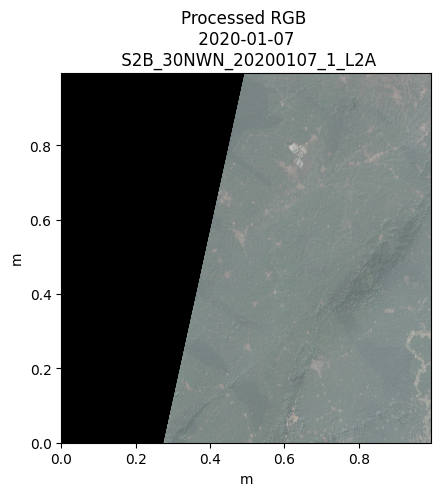

In [7]:
ss.plot(padding_m=100)

In [8]:
ss.ethz_array

array([[0.01915541, 0.01637668, 0.01359887, ..., 0.06536593, 0.06918836,
        0.0632566 ],
       [0.02840209, 0.01511599, 0.01035055, ..., 0.05076496, 0.05313842,
        0.0539576 ],
       [0.06519403, 0.04738703, 0.0181451 , ..., 0.04842485, 0.05229048,
        0.0586246 ],
       ...,
       [0.7605494 , 0.77772117, 0.7964957 , ..., 0.13181643, 0.13298681,
        0.13845307],
       [0.66825604, 0.69032544, 0.72495687, ..., 0.13478269, 0.1400255 ,
        0.14364088],
       [0.589036  , 0.6174018 , 0.6639105 , ..., 0.13166873, 0.13455734,
        0.13016656]], shape=(10980, 10980), dtype=float32)

In [12]:
ss.ethz_array

array([[0.01915541, 0.01637668, 0.01359887, ..., 0.06536593, 0.06918836,
        0.0632566 ],
       [0.02840209, 0.01511599, 0.01035055, ..., 0.05076496, 0.05313842,
        0.0539576 ],
       [0.06519403, 0.04738703, 0.0181451 , ..., 0.04842485, 0.05229048,
        0.0586246 ],
       ...,
       [0.7605494 , 0.77772117, 0.7964957 , ..., 0.13181643, 0.13298681,
        0.13845307],
       [0.66825604, 0.69032544, 0.72495687, ..., 0.13478269, 0.1400255 ,
        0.14364088],
       [0.589036  , 0.6174018 , 0.6639105 , ..., 0.13166873, 0.13455734,
        0.13016656]], shape=(10980, 10980), dtype=float32)

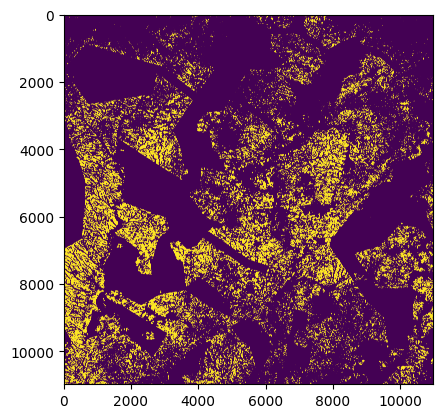

In [13]:
plt.imshow(ss.ethz_array > 0.95)